# 5. Pilas, colas y colas de prioridad

## **Pilas LAST IN FIRST OUT**
Una **pila**, también llamada *stack* o *pushdown* en inglés, es una lista de elementos en la cual todas las operaciones se realizan solo en un extremo de la lista.

Todas las operaciones se hacen en el extremo superior, por ello, los elementos salen en el orden contrario al que entran (van saliendo por el lado superior, el primero que entra es el ultimo que sale).

5-8-4-1 => 1-4-8-5

![pila](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/pila.png?raw=1)

Las dos operaciones básicas son **push** (apilar), que agrega un elemento encima de todos, y **pop** (desapilar), que extrae el elemento del tope de la pila. Más precisamente, si `s` es un objeto de tipo Pila, están disponibles las siguientes operaciones:

* `s.push(x)`: apila x en el tope de la pila `s` (ingresamos un elemento en el tope de la lista)
* `x=s.pop()`: extrae y retorna el elemento del tope de la pila `s` (sacamos un elemento del tope de la lista)
* `b=s.is_empty()`: retorna verdadero si la pila `s` está vacía, falso si no

In [ ]:
class Pila:
    def __init__(self):
        self.s=[]
    def push(self,x):
        self.s.append(x)
    def pop(self):
        assert len(self.s)>0
        return self.s.pop() # pop de lista, no de Pila
    def is_empty(self):
        return len(self.s)==0

In [ ]:
a=Pila()
a.push(10)
a.push(20)
print([elemento for elemento in a.s])
print(a.pop())
print([elemento for elemento in a.s])
a.push(30)
print(a.pop())
print(a.pop())
print([elemento for elemento in a.s])

Las listas son heterogeneas, ocupan espacio y no son optimas para el almacenamiento de datos. Es por ello que se cambia de listas a arreglos de numpy, los cuales son homogeneos (contienen solo un tipo de dato).

Usando arreglos (rellenos de ceros inicialmente) se puede definir un largo finito de la pila (a diferencia de las listas que pueden ser infinitas y se guardan en memoria). Los elementos se agregan por la derecha y ocupan el espacio mas a la derecha vacío.

![pila-arreglo](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/pila-arreglo.png?raw=1)

In [2]:
import numpy as np
class Pila:
    def __init__(self,maxn=100):
        self.s=np.zeros(maxn) # arreglo original
        self.n=0              # contador para saber la cantidad de elementos que ocupan un espacio dentro del arreglo
    def push(self,x):
        assert self.n<len(self.s)-1 # quedan espacios libres para rellenar
        self.s[self.n]=x            # rellenamos la primera posicion vacía (mas a la izquierda, no a la derecha) con el valor x
        self.n+=1                   # aumentamos el contador en 1 por el nuevo elemento agregado
    def pop(self):
        assert self.n>0         # verficar que hay elementos dentro de la pila
        self.n-=1               # disminuimos el contador para 'eliminar' TEORICAMENTE el elemento
        return self.s[self.n]   # se empieza a considerar la posicion anterior como el ultimo elemento relleno (pero el valor original ultimo sigue dentro de la pila, no se elimina, solo se cambia el 'puntero' por asi decirlo)
    def is_empty(self):
        return self.n==0       # para verificar si está vacía la pila (n representa la cantidad de elementos dentro de la pila, y por consecuente, podría servir como un puntero para el ultimo elemento ocupado en la pila)

In [6]:
a=Pila(10)
a.push(10)
a.push(20)
print(a.pop())
a.push(30)
print(a.pop())
print(a.pop())
print(a.s)
b=Pila()
print(b.s)

20.0
30.0
10.0
[10. 30.  0.  0.  0.  0.  0.  0.  0.  0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


Debido a  la limitación que se tiene por el tamaño máximo del arreglo, se implementan pilas a traves de listas enlazadas: estas son listas que contienen nodos, los cuales tienen información y un puntero, el cual indica cual es el siguiente elemento de la lista. Recordar que para eliminar un nodo, solo se debe cambiar de direccion el puntero del nodo anterior al que se quiere eliminara el elemento que está despues del que se quiere eliminar, asi:

3 -> 4 -> 5 ->

Eliminar 4: 3 -> 5 (el 4 queda flotando sin posición/puntero y se elimina)

![pila-lista](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/pila-lista.png?raw=1)

In [7]:
class NodoLista:
    def __init__(self,info,sgte=None):
        self.info=info  # información
        self.sgte=sgte  # puntero
class Pila:
    def __init__(self):
        self.tope=None
    def push(self,x):
        self.tope=NodoLista(x,self.tope)  # se agrega un nodo en el tope de la lista
    def pop(self):
        assert self.tope is not None  # si el ultimo elemento no es vacío
        x=self.tope.info              # se guarda la info del tope en una variable
        self.tope=self.tope.sgte      # el siguiente elemento se convierte en el nuevo tope
        return x                      # se retorna la info del elemento eliminado
    def is_empty(self):
        return self.tope is None      # si el tope es None significa que no hay nodos y la lista está vacía

In [25]:
a=Pila()
a.push(10)
a.push(20)
a.push(30)
print(a.pop())
a.push(30)
a.pop()
a.pop()

actual = a.tope
while actual is not None:  # Mientras queden nodos por recorrer
    print(actual.info)
    actual = actual.sgte

30
10


#### Evaluación de notación polaca
Si se tiene una fórmula en notación polaca, se puede calcular su valor usando una pila, inicialmente vacía.
Los símbolos de la fórmula se van leyendo de izquierda a derecha, y:

* si el símbolo es un número, se le hace `push` en la pila
* si el símbolo es un operador, se hacen dos `pop`, se efectúa la operación indicada entre los dos datos obtenidos, y el resultado se agrega de vuelta a la pila con `push`

Se van realizando los calculos dentro de la pila, por lo que consecutivamente se van ingresando los numeros y, cuando aparece un operador, se saca/pop el operador y luego el numero almacenado, se opera, y luego se guarda de nuevo.

Al terminar, si la fórmula estaba bien formada, debe haber solo un elemento en la pila, que es el resultado de la evaluación de la fórmula.

In [ ]:
def eval_polaca(formula):
    a=Pila()                         # se crea una pila para ir almacenando elementos hasta que salga un operador
    for x in formula.split():        # se separa la ecuacion en espacios para poder acceder a solo un valor
        if x.isnumeric():
            a.push(int(x))           # si es un numero se ingresa a la pila
        else:                        # si no es un numero, tiene que ser un operador, por lo que se usa else
            v=a.pop()                # se guardan los dos valores numericos de los ingresados a la pila en variables
            u=a.pop()                # se operan las variables con el operador encontrado
            if x=="+":
                w=u+v
            elif x=="-":
                w=u-v
            elif x=="*":
                w=u*v
            elif x=="/":
                w=u/v
            else:
                print("Operador desconocido:",x)
                return 0
            a.push(w)               # se guarda el resultado de la operacion enn la pila y es o unico que queda
    return a.pop()                  # se muestra el resultado final

In [ ]:
formula=input('Escriba la fórmula en notación polaca: ')
print("Resultado: ",eval_polaca(formula))

### Recuerdo de recorridos
La diferencia entre cada recorrido depende exclusivamente de **cuándo se procesa el nodo Raíz** con respecto a sus subárboles Izquierdo (Iz) y Derecho (Der).

#### 1. Preorden
* **Fórmula:** Raíz $\rightarrow$ Izquierdo $\rightarrow$ Derecho
* **Lógica:** Primero visitas la raíz, luego todo el subárbol izquierdo y al final todo el derecho.
* **Uso:** Copiar estructuras de árboles o evaluar expresiones matemáticas.

#### 2. Inorden (Orden Simétrico)
* **Fórmula:** Izquierdo $\rightarrow$ Raíz $\rightarrow$ Derecho
* **Lógica:** Primero recorres todo el subárbol izquierdo, luego visitas la raíz y al final el derecho.
* **Uso:** En un *Árbol Binario de Búsqueda (BST)*, este recorrido entrega los elementos ordenados de menor a mayor.

#### 3. Postorden
* **Fórmula:** Izquierdo $\rightarrow$ Derecho $\rightarrow$ Raíz
* **Lógica:** Primero recorres todo el subárbol izquierdo, luego todo el derecho y al final de todo visitas la raíz.
* **Uso:** Borrar o liberar la memoria de un árbol (se deben eliminar los hijos antes de eliminar al padre).

---

### Ejemplo Rápido
Para un árbol simple estructurado como:
    A (Raíz)
   / \
  B   C

* **Preorden:** `A -> B -> C`  *(Raíz al principio)*
* **Inorden:** `B -> A -> C`  *(Raíz al medio)*
* **Postorden:** `B -> C -> A`  *(Raíz al final)*

#### Recorrido no recursivo de un árbol binario
Si se quiere recorrer un arbol binario en pre orden, es decir primero la raiz, luego su hijo izquiero y luego el hijo derecho, entonces se usa una pila como una to-do list, en donde primero se visita la raiz y luego se guardan en la pila el hijo DERECHO y luego el IZQUIERDO, pues despues se haria pop en el orden inverso, es decir, se hace pop al izquierdo primero y luego al derecho, justo lo que es el preorden.

In [29]:
class Nodo:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

class Arbol:
    def __init__(self,raiz=None):
        self.raiz=raiz

    def preorden(self):
        print("Preorden no recursivo optimizado:", end=" ")
        s=Pila()           # se crea la pila como to-do list
        s.push(self.raiz)  # se guarda la raiz
        while not s.is_empty():  # mientras la pila tenga elementos
            p=s.pop()            # se saca el ultimo elemento y se guarda su contenido en una variable
            while p is not None: # mientras el elemento no esté vacío
                print(p.info, end=" ")  # se muestra el valor info (se parte con raiz, luego con hijo izquierdo y hijos, luego hijo derecho de la raiz, y asi...)
                s.push(p.der)           # se guarda en la to-do list el hijo derecho pq se lee despues del izquierdo
                p=p.izq                 # se avanza al hijo izquierdo
        print()

In [30]:
a=Arbol(
    Nodo(
        Nodo(
            Nodo(None,15,None),
            20,
            Nodo(
                Nodo(None,30,None),
                35,
                None
            )
        ),
        42,
        Nodo(
            Nodo(
                Nodo(
                    Nodo(None,65,None),
                    72,
                    Nodo(None,81,None)
                ),
                90,
                None
            ),
            95,
            None
        )
       )
)

In [31]:
a.preorden()

Preorden no recursivo optimizado: 42 20 15 35 30 95 90 72 65 81 


## **Colas FIRST IN FIRST OUT**

Una cola es una lista en que los elementos ingresan por un extremo y salen por el otro. Debido a que los elementos van saliendo en orden de llegada, una cola también se llama "lista FIFO", por "First-In-First-Out".

![cola](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/cola.png?raw=1)

Las dos operaciones básicas son **enq** (encolar), que agrega un elemento al final de todos, y **deq** (desencolar), que extrae el elemento que encabeza la cola. Más precisamente, si `q` es un objeto de tipo Cola, están disponibles las siguientes operaciones:

* `q.enq(x)`: encola x al final de la cola `q`
* `x=q.deq()`: extrae y retorna el elemento a la cabeza de la cola `q`
* `b=q.is_empty()`: retorna verdadero si la cola `q`está vacía, falso si no

### Implementación usando listas de Python

Tal como hicimos en el caso de las pilas, es muy simple implementar colas usando las listas de Python, pero no tenemos mucho control sobre la eficiencia del resultado:

In [ ]:
class Cola:
    def __init__(self):
        self.q=[]
    def enq(self,x):
        self.q.insert(0,x)
    def deq(self):
        assert len(self.q)>0
        return self.q.pop()
    def is_empty(self):
        return len(self.q)==0


In [ ]:
a=Cola()
a.enq(72)
a.enq(36)
print(a.deq())
a.enq(20)
print(a.deq())
print(a.deq())
a.enq(61)
print(a.deq())

72
36
20
61


### Implementación usando un arreglo

Tambien se pueden implementar usando arreglos, lo cual tiene el beneficio de que funciona de forma circular, es decir, la siguiente posición a la ultima, es la primera.

![cola-arreglo](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/cola-arreglo.png?raw=1)

In [1]:
import numpy as np
class Cola:
    def __init__(self,maxn=100):
        self.q=np.zeros(maxn)    # se crea el arreglo
        self.n=0                 # se crea el contador de elementos dentro
        self.cabeza=0            # se define el valor de la cabeza
    def enq(self,x):
        assert self.n<len(self.q)-1                   # se verifica que la cola no esté llena y que efectivamente se puedan encolar elementos
        self.q[(self.cabeza+self.n)%len(self.q)]=x    # x se guardará en la posición del RESTO de la posicion de la cabeza + los elementos presentes dividido por el largo de q (si está ordenada es cabeza=0 + n elementos o cabeza = 6 + 4 elementos // 7 = 3)
        self.n+=1                                     # se aumenta en 1 porque se agregó un elemento
    def deq(self):
        assert self.n>0                             # se verifica que hayan elementos para eliminar
        x=self.q[self.cabeza]                       # se accede al primer elemento de la cola (cabeza)
        self.cabeza=(self.cabeza+1)%len(self.q)     # se fija la cabeza en la posicion del resto de la division entre el siguiente elemento a eliminar dividido por el tamaño
        self.n-=1                                   # se disminuye en 1 porque se eliminó un elemento
        return x
    def is_empty(self):
        return self.n==0

In [2]:
a=Cola(3) # para forzar circularidad
a.enq(72)
a.enq(36)
print(a.deq())
a.enq(20)
print(a.deq())
print(a.deq())
a.enq(61)
print(a.deq())

72.0
36.0
20.0
61.0


### Colas de Prioridad

Hay muchas situaciones en que los elementos que esperan en una cola deben ir siendo atendidos no por orden de llegada, sino de acuerdo a algún criterio de _prioridad_.
En esos casos, no nos sirve la cola como la hemos visto, sino que se necesita un nuevo tipo de estructura.

Una cola de prioridad es un TDA que consiste de un conjunto de datos que poseen un atributo (llamado su _prioridad_) perteneciente a algún conjunto ordenado, y en el cual se pueden ejecutar dos operaciones básicas: **insertar** un nuevo elemento con una prioridad cualquiera y **extraer** el elemento de máxima prioridad.

Más específicamente, las operaciones permitidas son:

* `q.insert(x)`: inserta un elemento de prioridad x en la cola de prioridad `q`
* `x=q.extract_max()`: extrae y retorna el elemento de máxima prioridad de la cola de prioridad `q`
* `b=q.is_empty()`: retorna verdadero si la cola de prioridad `q`está vacía, falso si no

Definir qué significa tener "máxima prioridad" depende de la aplicación que queramos darle a la cola de prioridad. En los ejemplos de este capítulo, supondremos que mejor prioridad corresponde a un mayor valor numérico, pero por simetría también sería válido el criterio opuesto.

### Implementación usando un _Heap_

Un heap es un árbol binario de una forma especial, que permite su almacenamiento sin usar punteros.

Este árbol se caracteriza porque tiene todos sus niveles llenos, excepto posiblemente el último, y en ese último nivel, los nodos están lo más a la izquierda posible.

![heap-arbol](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/heap-arbol.png?raw=1)

Un árbol que cumpla esta condición diremos que tiene "forma de heap".

Los números bajo cada nodo corresponde a una numeración por niveles, y esa numeración se utiliza para almacenar cada elemento en el casillero respectivo de un arreglo:

![heap-arreglo](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/heap-arreglo.png?raw=1)

Este arreglo contiene toda la información necesaria para representar al árbol. En efecto, tenemos que la raíz está en el casillero $0$, y además

$$
\begin{align}
\text{hijos del nodo }j &= \{2j+1,2j+2\} \\
\text{padre del nodo }k &= \left\lfloor \frac{k-1}{2} \right\rfloor
\end{align}
$$

Si hay $n$ casilleros ocupados en el arreglo, cualquier subíndice que sea mayor o igual a $n$ corresponde a un nodo inexistente.

Un heap puede utilizarse para implementar una cola de prioridad almacenando los datos de modo que las llaves estén siempre ordenadas de arriba a abajo (a diferencia de un árbol de búsqueda binaria, que ordena sus llaves de izquierda a derecha). En otras palabras, el padre debe tener siempre mejor prioridad que sus hijos. Un árbol que cumple esta condición diremos que tiene "orden de heap", y también se dice que es un "árbol de prioridad".

Por lo tanto, un heap debe satisfacer un invariante consistente en dos condiciones:

* Condición estructural: el árbol debe tener "forma de heap"
* Condición de orden: el árbol debe tener "orden de heap"

#### Inserción

La inserción se realiza agregando el nuevo elemento en la primera posición libre del heap, esto es, el próximo nodo que debería aparecer en el recorrido por niveles o, equivalentemente, un casillero que se agrega al final del arreglo.

Después de agregar este elemento, la condición estructural se cumple, pero la condición de orden no tiene por qué cumplirse. Para resolver este problema, si el nuevo elemento es mayor que su padre, se intercambia con él, y ese proceso se repite mientras sea necesario. Una forma de describir esto es diciendo que el nuevo elemento "trepa" en el árbol hasta alcanzar el nivel correcto según su prioridad.

![heap-ins](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/heap-ins.gif?raw=1)

Como la altura del árbol es $\log_2{n}$ y en cada nivel se hace un trabajo constante, el tiempo que demora esta operación en el peor caso es $\Theta(\log{n})$.

#### Extracción del máximo

El máximo evidentemente está en la raíz del árbol (casillero 0 del arreglo). Al sacarlo de ahí, podemos imaginar que ese lugar queda vacante. Para llenarlo, tomamos al último elemento del heap y lo trasladamos al lugar vacante. En caso de que no esté bien ahí de acuerdo a su prioridad (¡que es lo más probable!), lo hacemos descender intercambiándolo siempre con el mayor de sus hijos. Decimos que este elemento "se hunde" hasta su nivel de prioridad.

![heap-extract](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/heap-extract.gif?raw=1)

Esta operación también demora un tiempo proporcional a la altura del árbol en el peor caso, esto es, $\Theta(\log{n})$.


#6. Diccionarios

Los diccionarios son estructuras de tipo **{** **llave**:valor **}** que tienen las siguientes operaciones:

* `r=d.search(x)`: buscar el elemento de llave `x`, retornar un resultado que permita ubicarlo, o `None` si no está
* `d.insert(x)`: insertar un elemento de llave `x`, evitando crear una llave duplicada
* `d.delete(x)`: eliminar el elemento de llave `x`, el cual debe estar en el diccionario

Para buscar una llave y su cantidad, se debe buscar como diccionario['llave']

Para agregar una nueva llave, se debe colocar diccionario['nueva llave']=valor

Para eliminar una llave se usa diccionario.pop('llave')

In [5]:
distancia = {'Valparaíso':102, 'Concepción': 433, 'Arica': 1664, 'Puerto Montt': 912, 'Rancagua': 80}
print(distancia['Arica'])
distancia['Talca']=237
print(distancia)
# print(distancia['La Serena']) tira error
print(distancia.get('Rancagua'), distancia.get('La Serena')) # estp arroja None si no está
distancia.pop('Rancagua')
print(distancia)

1664
{'Valparaíso': 102, 'Concepción': 433, 'Arica': 1664, 'Puerto Montt': 912, 'Rancagua': 80, 'Talca': 237}
80 None
{'Valparaíso': 102, 'Concepción': 433, 'Arica': 1664, 'Puerto Montt': 912, 'Talca': 237}


## Búsqueda secuencial

La manera más simple de implementar un diccionario es con una lista desordenada de llaves, en la cual se hace búsqueda secuencial. La inserción es especialmente eficiente si obviamos chequear por duplicados, y la eliminación es eficiente una vez que sabemos dónde está la llave.

In [6]:
import numpy as np

In [8]:
class Lista_secuencial:
    def __init__(self, size=100):
        self.a=np.zeros(size,dtype=int)   # arreglo con ceros
        self.n=0                          # contador de elementos
    def insert(self,x):
        assert self.n<len(self.a)         # se verifica que el arreglo no esté lleno para poder agregar elementos
        self.a[self.n]=x                  # se inserta el elemento en la posicion vacía (que coincide con el numero de elementos en el arreglo)
        self.n+=1                         # se aumenta en 1 el contador (quedamos en una posicion vacía)
    def search(self,x):
        for k in range(0,self.n):         # para cada posición que contiene un elemento
            if self.a[k]==x:              # se verifica si es el elemento que se está buscando
                return k                  # se entrega la posición en la que se encontró
        return None
    def delete(self,x):
        k=self.search(x)                  # se busca el elemento y se obtiene su posición k
        self.a[k]=self.a[self.n-1]        # como no importa el orden, movemos el último elemento del arreglo al lugar del que se quiere eliminar
        self.n-=1                         # se elimina uno en el contador y el ultimo elemento deja de ser valido (se pseudo-elimina)

In [9]:
d=Lista_secuencial()
d.insert(30)
d.insert(10)
d.insert(25)
print(d.search(10))
print(d.search(80))
d.delete(30)
print(d.search(30))

1
None
None


La búsqueda secuencial también se puede implementar con una lista enlazada, en cuyo caso será más simple insertar al inicio.

En cualquier caso, la búsqueda demora tiempo $\Theta(n)$.
Para estimar el costo promedio, suponemos que todos los elementos son igualmente probables de ser accesados y que el costo de buscar a un elemento que es el $k$-ésimo de la lista es $k$. Por lo tanto, el costo promedio es

$$
\frac{1}{n}\sum_{1\le k \le n} k = \frac{n+1}{2}=\Theta(n)
$$

Por lo tanto, este tipo de implementación solo será adecuada para conjuntos muy pequeños.

## Búsqueda secuencial con probabilidades de acceso no uniformes

En la práctica, es muy raro que las probabilidades de acceso a los elementos sean uniformes. Con frecuencia hay algunos elementos que son mucho más populares que otros, y empíricamente a menudo se observan distribuciones de tipo "ley de potencias", con probabilidades de tipo

$$
p_k \propto \frac{1}{k^{\alpha}}
$$

para algún $\alpha$. Para el caso $\alpha=1$ esto se llama Ley de Zipf.

Si un conjunto de datos tiene elementos con probabilidades de acceso diferentes, entonces para la búsqueda secuencial el orden en que estén los elementos en la lista hace una diferencia.

### Caso 1. Probabilidades conocidas

Si las probabilidades de acceso son conocidas, es fácil ver que el orden óptimo es en orden decreciente de probabilidad.

Más precisamente, si los elementos son $X_1, X_2,\ldots,X_n$ con probabilidades de acceso $p_1,p_2,\ldots,p_n$ respectivamente, y si están ordenados de modo que $p_1\ge p_2\ge p_3\ge \cdots$, entonces el costo esperado de búsqueda óptimo es

$$
C_{OPT} = \sum_{1\le k\le n} k p_k
$$

Tomemos como ejemplo el capítulo 1 de "El Quijote" (en minúsculas y sin puntuación para simplificar su proceso), cuyo texto está en el archivo `cap1.txt`:

```
en un lugar de la mancha de cuyo nombre no quiero acordarme no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero adarga antigua
...
peregrino y significativo como todos los demás que a él y a sus cosas
había puesto
```

#### Acceso al archivo desde Colab

Si este notebook está usándose en Google Colab, el archivo se debe almacenar en la carpeta `Colab Notebooks` de Google Drive, y para que el código en Python pueda tener acceso a él se debe quitar los comentarios y ejecutar la siguiente celda:

In [ ]:
#from google.colab import drive
#drive.mount("/content/gdrive")
#%cd "/content/gdrive/My Drive/Colab Notebooks/"

El costo óptimo para un archivo dado se puede obtener con el siguiente código en Python, en el cual hacemos uso de los diccionarios provistos por el lenguaje:

In [ ]:
def calcula_costo_optimo(archivo): # lee el archivo, calcula frecuencias en orden descendente
    f=open(archivo,"r")
    texto=f.read()
    palabras=texto.split()
    frec={}
    for x in palabras:
        frec[x] = 1 if not x in frec else frec[x]+1
    lista=[]
    Copt=0
    costo=0
    for x in sorted(frec,key=frec.get,reverse=True):
        costo+=1
        Copt+=costo*frec[x]
        lista.append((frec[x],x))
    Copt/=len(palabras)
    f.close()
    return (Copt,lista)

Como resultado, mostramos el costo esperado de búsqueda en una lista ordenada de manera óptima (C_OPT) y las palabras más frecuentes:

In [ ]:
(c,L)=calcula_costo_optimo("cap1.txt")
print('C_OPT={:6.2f}\n'.format(c))
for k in range(0,9):
    print(L[k])

### Caso 2: Probabilidades desconocidas

Cuando las probabilidades son desconocidas, existen estrategias adaptativas, que van reordenando la lista dinámicamente a medida que los elementos son buscados, de modo de tratar de aproximar el orden óptimo. Hay dos técnicas que dan buenos resultados: "traspose" (TR) y "move to front" (MTF).

### Transpose

Esta técnica consiste en que cada vez que un elemento es accesado, se le mueve un lugar más adelante en la lista (a menos que ya esté en el primer lugar).
Esto se puede implementar ya sea en un arreglo o en una lista enlazada. En la siguiente implementación usaremos una lista enlazada con cabecera.

Si un elemento no se encuentra, simulamos como si hubiese estado al final de la lista. Para esto, mantendremos siempre disponible un nodo extra al final de la lista, en donde almacenaremos tentativamente la llave de búsqueda.
Si finalmente se encuentra en ese nodo, se le incorpora a la lista y se crea un nuevo nodo extra.

Para contabilizar el costo, el método `search` retorna el número de comparaciones de llaves que se hizo en la búsqueda.

In [15]:
pip install aed-utilities

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.6 MB/s eta 0:00:00


In [16]:
import aed_utilities as aed

In [17]:
class NodoLista:
    def __init__(self,info,sgte=None):
        self.info=info
        self.sgte=sgte

class Lista_TR:
    def __init__(self):
        self.extra=NodoLista(0)
        self.cabecera=NodoLista(0,self.extra)

    def search(self,x): # busca x (si no está lo inserta al final) y lo adelanta un lugar
                        # retorna el costo de búsqueda
        self.extra.info=x # agregamos x al final, en caso que no estuviera antes
        p=self.cabecera
        q=p.sgte

        # k cuenta el número de comparaciones de llaves
        if q.info==x: # x ya está primero en la lista, no hacemos nada
            k=1
        else:
            # buscamos del segundo en adelante
            r=q.sgte
            k=2
            while r.info!=x:
                (p,q,r)=(q,r,r.sgte)
                k+=1
            # r apunta al elemento buscado, lo movemos un lugar hacia adelante
            (p.sgte,q.sgte,r.sgte)=(r,r.sgte,q)
        if q.sgte is None: # se utilizó el nodo extra, agregamos uno nuevo
            self.extra=NodoLista(0)
            q.sgte=self.extra
        return k

    def imprimir(self):
        p=self.cabecera.sgte
        print("[",end=" ")
        while p is not self.extra:
            print(p.info,end=" ")
            p=p.sgte
        print("]")


In [18]:
def test(Lista_adaptativa): # test interactivo
    a=Lista_adaptativa()
    while True:
        x=input("x=")
        if x=="fin":
            return
        print("costo=",a.search(x),end=" ")
        a.imprimir()

In [ ]:
test(Lista_TR)

In [ ]:
def procesa(archivo,Lista_adaptativa): # lee el archivo y calcula costo promedio de búsqueda
    f=open(archivo,"r")
    texto=f.read()
    palabras=texto.split()
    npalabras=0
    costo_acum=0
    a=Lista_adaptativa()
    for x in palabras:
        costo_acum+=a.search(x)
        npalabras+=1
    print("Costo promedio de búsqueda= {:6.2f}".format(costo_acum/npalabras))
    f.close()

In [ ]:
procesa("cap1.txt",Lista_TR)

### Move-To-Front

Esta técnica consiste en que cada vez que un elemento es accesado, se le mueve al primer lugar de la lista (a menos que ya esté en el primer lugar). Si un elemento no se encuentra, simulamos como si hubiese estado al final de la lista.

In [ ]:
class Lista_MTF:
    def __init__(self):
        self.extra=NodoLista(0)
        self.cabecera=NodoLista(0,self.extra)

    def search(self,x): # busca x (si no está lo inserta al final) y luego lo mueve al primer lugar
        # retorna el costo de búsqueda
        self.extra.info=x # agregamos x al final, en caso que no estuviera antes
        p=self.cabecera
        q=p.sgte
        k=1 # cuenta el número de comparaciones de llaves
        while q.info!=x:
            (p,q)=(q,q.sgte)
            k+=1
        if q.sgte is None: # se utilizó el nodo extra, agregamos uno nuevo
            self.extra=NodoLista(0)
            q.sgte=self.extra
        if k>1:  # x no está primero, move to front
            (self.cabecera.sgte,p.sgte,q.sgte)=(q,q.sgte,self.cabecera.sgte) # se cambia q (elemento que se está analizando) por el siguiente al inicial (cabecera.sgte) y el anterior a q (q se movió) apunta al siguiente de q (se elimina q)
        return k

    def imprimir(self):
        p=self.cabecera.sgte
        print("[",end=" ")
        while p is not self.extra:
            print(p.info,end=" ")
            p=p.sgte
        print("]")

In [ ]:
test(Lista_MTF)

In [ ]:
procesa("cap1.txt",Lista_MTF)

En resumen, tenemos que para este texto en particular, el costo óptimo es 157.81, el costo promedio de TR es 208.74 y el de MTF es 188.82.

Si en lugar de considerar un caso se analiza matemáticamente el caso general, suponiendo que los accesos llegan independientemente siguiendo la distribución dada y que el algoritmo corre durante un tiempo que tiende a infinito, se puede demostrar que

$$
C_{OPT} \le C_{TR} \le C_{MTF} \le \frac{\pi}{2} C_{OPT}
$$

### Búsqueda en un arreglo ordenado: Búsqueda Binaria

Ya hemos visto anteriormente que si los datos están en un arreglo ordenado, podemos hacer una búsqueda binaria, la que demora tiempo $\lceil\log_2{(n+1)}\rceil=\Theta(\log{n})$ en el peor caso.

Esto es bastante eficiente, pero tiene el problema que agregar o eliminar datos del arreglo toma tiempo $\Theta(n)$ en el peor caso, por la necesidad de mantener el conjunto ordenado y compacto.
Un objetivo que perseguiremos en el resto de este capítulo es tratar de encontrar estructuras de datos que nos permitan buscar de manera tan eficiente como la búsqueda binaria, junto con inserciones y eliminaciones igualmente eficientes.

Pero antes de avanzar en esa dirección, consideremos la pregunta de si es posible buscar má rápido que la búsqueda binaria en el peor caso.

### Cota inferior para la búsqueda por comparaciones

Consideremos el problema de buscar una llave $x$ en un conjunto de tamaño 4, digamos $\{a,b,c,d\}$, con $a<b<c<d$. La siguiente figura ilustra una manera como podría hacerse esa búsqueda:

![decision-tree](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/decision-tree.png?raw=1)

Este tipo de figura se llama un *árbol de decisión*, y en él los rombos representan preguntas y los rectángulos, las salidas (outputs) del algoritmo.

Este árbol de decisión es uno entre la infinidad de árboles que podrían resolver el problema de la búsqueda. Lo importante que hay que observar es que todo algoritmo que funcione mediante comparaciones binarias (comparaciones con salidas "Sí/No") se puede representar por un árbol de decisión.

En este tipo de árbol tenemos que:

* La altura representa el número de comparaciones que hace el algoritmo en el peor caso, y
* El número de hojas (cajas rectangulares) debe ser mayor o igual al número de respuestas posibles que debe ser capaz de emitir el algoritmo.

Recordemos que si $N$ es el número de hojas y $h$ la altura, siempre se tiene $N\le 2^h$, de donde se deduce que
$h \ge \lceil\log_2{N}\rceil$ (porque la altura es un número entero), y en consecuencia, tenemos que

$$
\text{Peor caso} \ge \lceil\log_2{(\text{número de respuestas distintas})}\rceil
$$

Para el caso de la búsqueda binaria, tenemos que $N=n+1$, porque el algoritmo de búsqueda debe poder identificar a cada uno de los $n$ elementos, más la respuesta negativa cuando el elemento buscado no está. En consecuencia:

**Todo algoritmo que busque en un conjunto de tamaño $n$ mediante comparaciones binarias debe hacer al menos
$\lceil\log_2{(n+1)}\rceil$ comparaciones en el peor caso.**

Por lo tanto, la búsqueda binaria es óptima.

### Árboles de Búsqueda Binaria (ABBs)

Un *árbol de búsqueda binaria* (*ABB*) es un árbol binario en que todos sus nodos internos cumplen la siguiente propiedad: Si la llave almacenada en el nodo es $x$, entonces todas las llaves en su subárbol izquierdo son menores que $x$, y las llaves en el subárbol derecho son mayores que $x$.

![esquema-ABB2](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/esquema-ABB2.png?raw=1)

Los ABBs permiten realizar de manera eficiente (en promedio) las operaciones de inserción y búsqueda.

### Búsqueda en un ABB

La búsqueda es similar a una búsqueda binaria (de  ahí el nombre de estos árboles). Para buscar una llave $x$ se comienza en la raíz. Si $x$ se encuentra ahí, la búsqueda termina exitosamente. Si no está ahí, se continúa buscando  en el subárbol izquierdo si $x$ es menor que la raíz, o en el subárbol derecho si $x$ es mayor que la raíz. Si se llega a una hoja (nodo externo), la búsqueda concluye infructuosamente.

### Inserción en un ABB

Para insertar una llave $x$ en un ABB, se realiza una búsqueda, que debe ser infructuosa, y la hoja en donde termina la búsqueda se reemplaza por un nodo interno conteniendo la llave $x$, con dos nuevas hojas como hijos.

![insercioABB](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/insercionABB.gif?raw=1)

### Implementación recursiva

Los algoritmos de un ABB se prestan de manera natural a ser programados de manera recursiva, especialmente con la representación explícita de los nodos externos:

In [20]:
class Nodoi:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

    def search(self,x):
        if x==self.info:
            return self
        if x<self.info:
            return self.izq.search(x)
        else:
            return self.der.search(x)

    def insert(self,x):
        assert x!=self.info
        if x<self.info:
            return Nodoi(self.izq.insert(x),self.info,self.der) # se va creando el nuevo nodo hacia abajo con self.izq.insert(x),self.info,self.der y cuando self.izq es Nodoe, se crea el nodo final con x y sus dos nuevas hojas
        else:
            return Nodoi(self.izq,self.info,self.der.insert(x))

    def __str__(self):
        return "("+self.izq.__str__()+str(self.info)+self.der.__str__()+")"

class Nodoe:
    def __init__(self):
        pass

    def search(self,x):
        return None

    def insert(self,x):
        return Nodoi(Nodoe(),x,Nodoe())   # se crea el nuevo nodo (que antes era una hoja) con padre a x y nuevos dos hijos

    def __str__(self):
        return"☐"

class Arbol:
    def __init__(self,raiz=Nodoe()):
        self.raiz=raiz

    def insert(self,x):
        self.raiz=self.raiz.insert(x)

    def search(self,x):
        return self.raiz.search(x)

    def __str__(self):
        return self.raiz.__str__()

    def dibujar(self):
      btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der", classNone=Nodoe, drawNull=True)
      btd.draw_tree(self, "raiz")

Hemos incluído una función `__str__` para poder visualizar (de forma algo rudimentaria) el árbol construído.

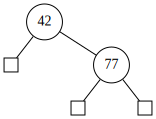

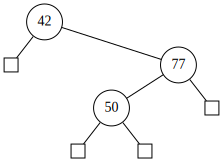

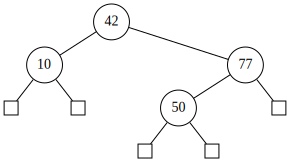

In [22]:
a=Arbol()
a.insert(42)
a.insert(77)
a.dibujar()
a.insert(50)
a.dibujar()
a.insert(10)
a.dibujar()

Para probar nuestra implementación, definiremos una función `test`:

In [23]:
def test(a,x):
    print(x, "está" if a.search(x) is not None else "no está")

In [24]:
test(a,50)
test(a,90)

50 está
90 no está


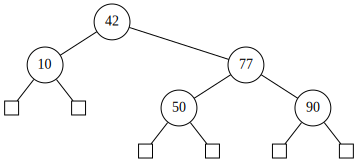

90 está


In [25]:
a.insert(90)
a.dibujar()
test(a,90)

### Implementación no recursiva

Las operaciones de búsqueda e inserción en el árbol no necesitan programarse recursivamente, porque se pueden realizar en una sola pasada de arriba a abajo, sin necesidad de volver hacia arriba. En este caso, toda esa funcionalidad se implementa dentro de la clase `Arbol`:

In [26]:
class Nodoi:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

    def __str__(self):
        return "("+self.izq.__str__()+str(self.info)+self.der.__str__()+")"

class Nodoe:
    def __init__(self):
        pass

    def __str__(self):
        return"☐"

class Arbol:
    def __init__(self,raiz=Nodoe()):
        self.raiz=raiz

    def insert(self,x):
        if isinstance(self.raiz, Nodoe):
            self.raiz=Nodoi(Nodoe(),x,Nodoe())
            return
        p=self.raiz
        while True:
            assert x!=p.info
            if x<p.info:
                if isinstance(p.izq, Nodoe):
                    p.izq=Nodoi(Nodoe(),x,Nodoe())
                    return
                p=p.izq
            else: # x>p.info
                if isinstance(p.der, Nodoe):
                    p.der=Nodoi(Nodoe(),x,Nodoe())
                    return
                p=p.der

    def search(self,x):
        p=self.raiz
        while not isinstance(p, Nodoe):
            if x==p.info:
                return p
            p=p.izq if x<p.info else p.der
        return None

    def __str__(self):
        return self.raiz.__str__()

    def dibujar(self):
      btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der", classNone=Nodoe, drawNull=True)
      btd.draw_tree(self, "raiz")

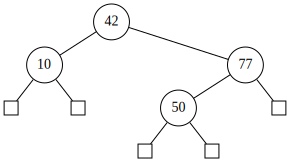

In [27]:
a=Arbol()
a.insert(42)
a.insert(77)
a.insert(50)
a.insert(10)
a.dibujar()

In [28]:
test(a,50)
test(a,90)

50 está
90 no está


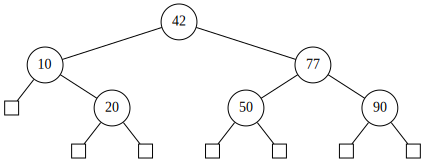

In [30]:
a.insert(20)
a.dibujar()

### Eliminación en un ABB

La eliminación de una llave $x$ es sencilla de efectuar en algunos casos, pero el caso complicado es cuando la llave tiene dos hijos:

#### Eliminación de una llave sin hijos

En este caso, el nodo interno que contiene a $x$ desaparece y en su lugar queda un nodo externo:

![eliminacionABB1](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/eliminacionABB1.gif?raw=1)

#### Eliminación de una llave con 1 hijo

En este caso, el padre de la llave $x$ pasa a apuntar al único hijo de $x$:

![eliminacionABB2](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/eliminacionABB2.gif?raw=1)

#### Eliminación de una llave con 2 hijos

Si $x$ tiene 2 hijos, no podemos eliminarla directamente, pero sí podemos eliminar a la que la sigue en orden ascendente, digamos $y$. Se puede demostrar que $y$ necesariamente es unos de los dos casos anteriores, de modo que es fácil de eliminar. Luego de concluído ese proceso, escribimos $y$ en lugar de $x$ en el campo `info` del nodo respectivo.

![eliminacionABB3](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/eliminacionABB3.gif?raw=1)

Por simetría, esto mismo podría haberse hecho con la llave que sigue a $x$ en orden descendente.

El análisis del costo esperado de búqueda que hicimos anteriormente es válido si solo hay inserciones. El análisis en el caso en que se incluyen eliminaciones es un un problema matemáticamente muy complicado, y sigue siendo un problema abierto. La evidencia experimental indica que se obtienen mejores resultados si se alterna o si se aleatoriza al elegir entre sucesor o el predecesor de $x$ en caso que haya que elegir.

#7. Ordenación

#8. Búsqueda en texto

#9. Compresión de datos

# 10. Grafos